# Index / Volatility Divergence Signals

## Workflow overview

This notebook demonstrates a market-regime signal based on divergence between an equity index and volatility. The workflow defines an analysis window, computes entry and exit signals, reviews the generated signal tables, and inspects the resulting return stream. It is intended as an interpretable algorithmic-trading research example.


### Execution environment

This notebook uses live Yahoo Finance data and requires network access. Run it from the repository root. It does not upgrade packages automatically; in a fresh environment, install the release shown in `pyproject.toml` before execution.

In [ ]:
# Fresh environment only: %pip install "riskoptima==2.7.1"

In [1]:
from riskoptima import RiskOptima
print(RiskOptima.VERSION)

2.7.1


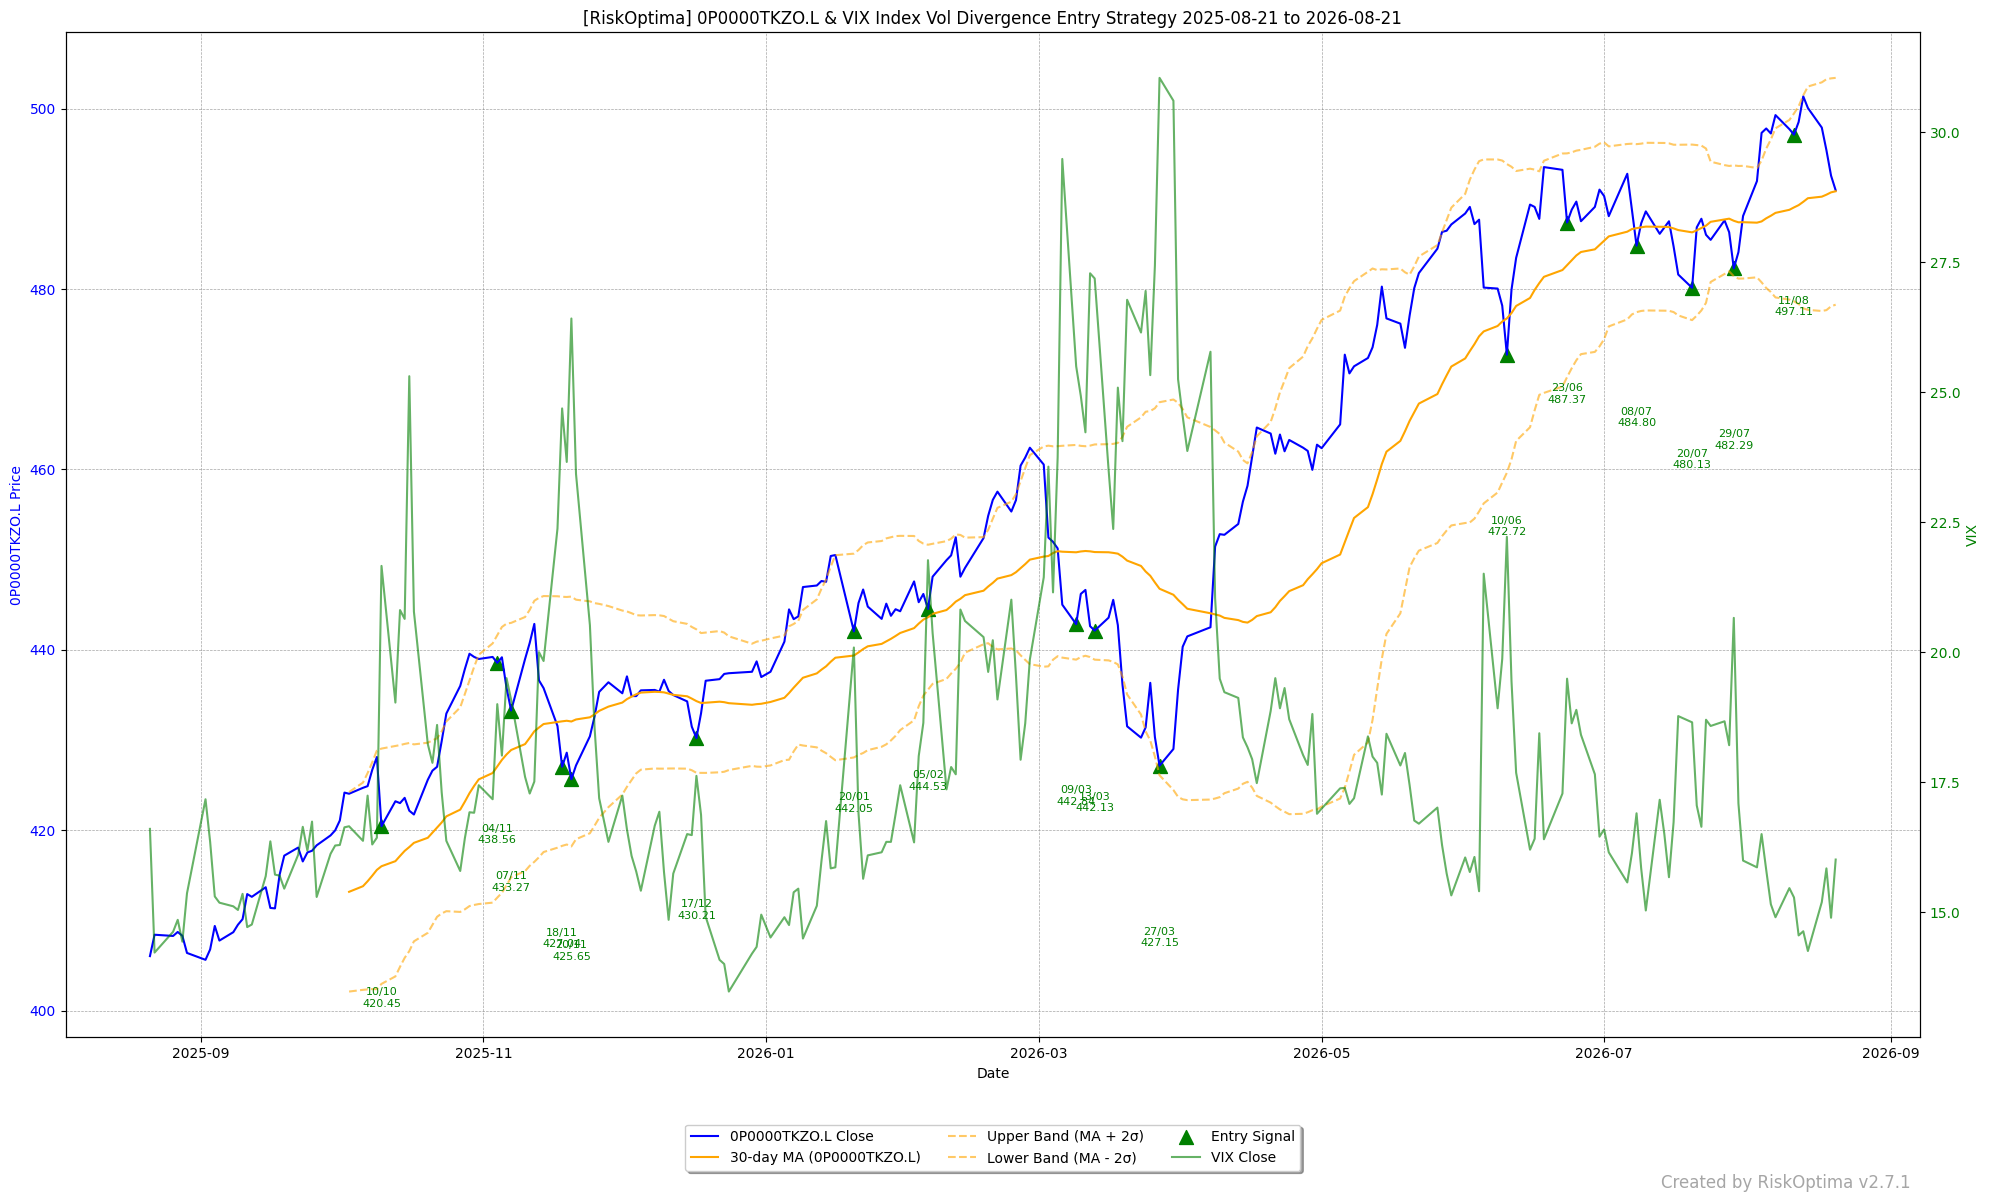

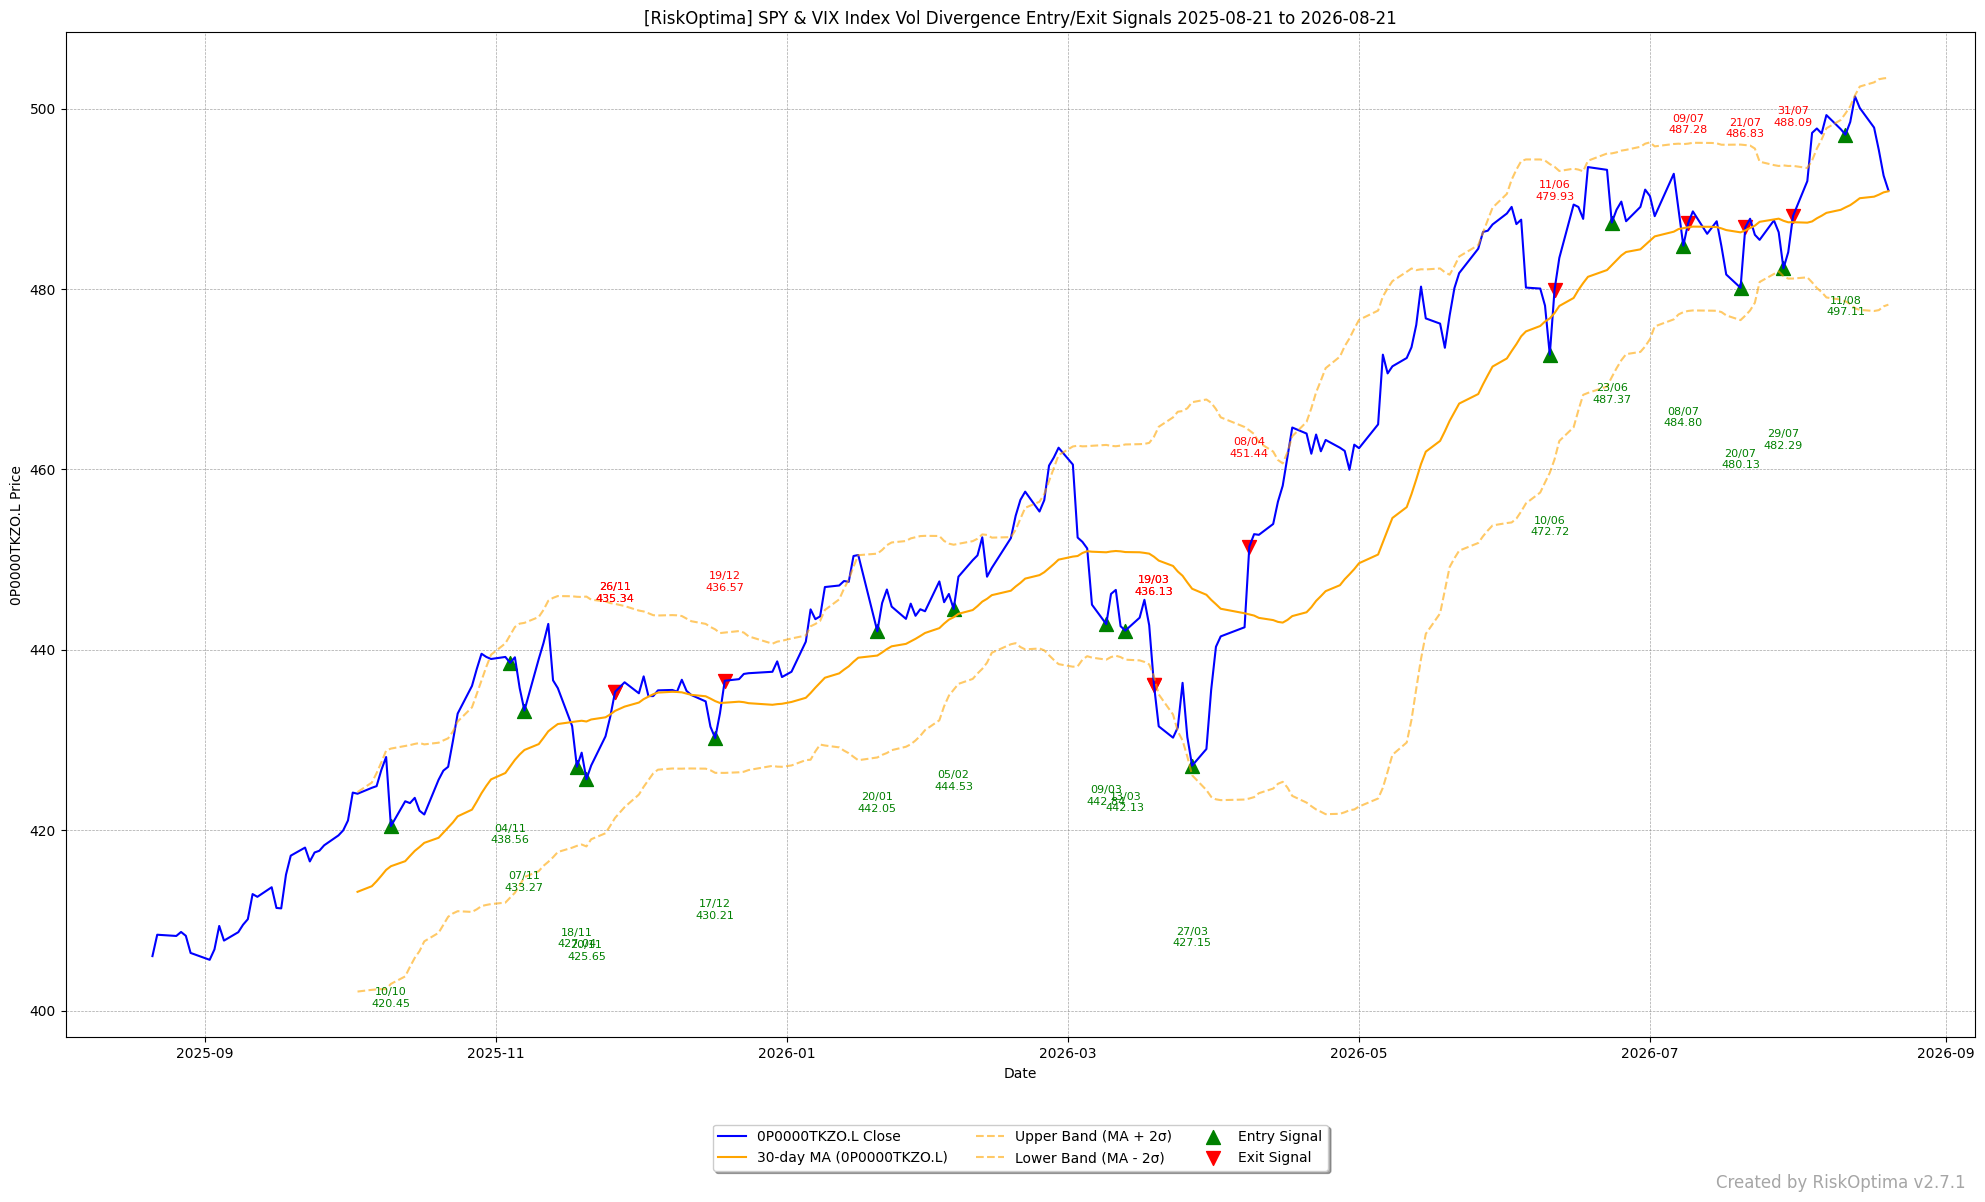

In [2]:
ANALYSIS_START_DATE = RiskOptima.get_previous_year_date(RiskOptima.get_previous_working_day(), 1)
ANALYSIS_END_DATE   = RiskOptima.get_previous_working_day()

df_signals, df_exits, returns = RiskOptima.run_index_vol_divergence_signals(start_date=ANALYSIS_START_DATE, 
                                                                            end_date=ANALYSIS_END_DATE,
                                                                            symbol_base = '0P0000TKZO.L')

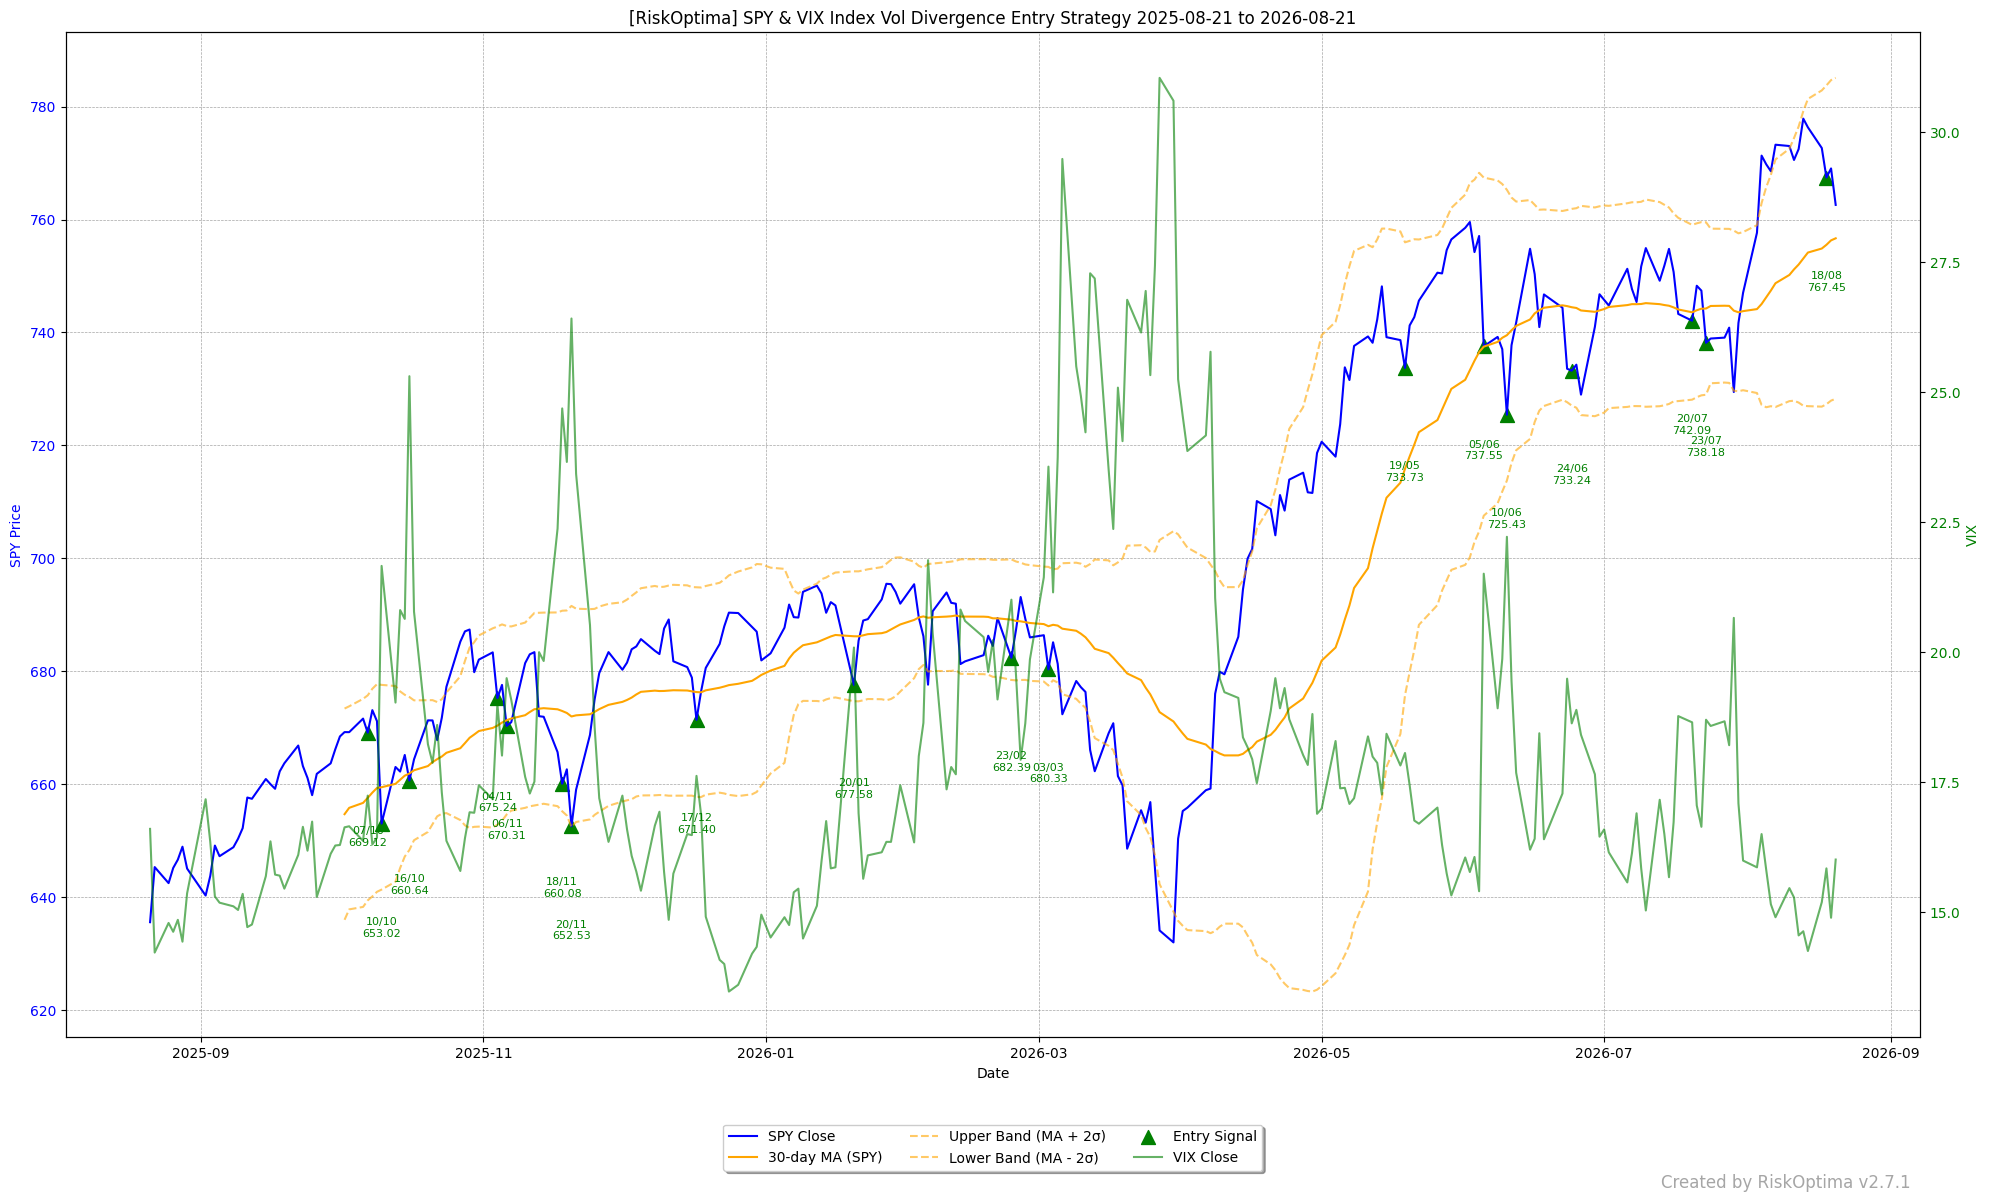

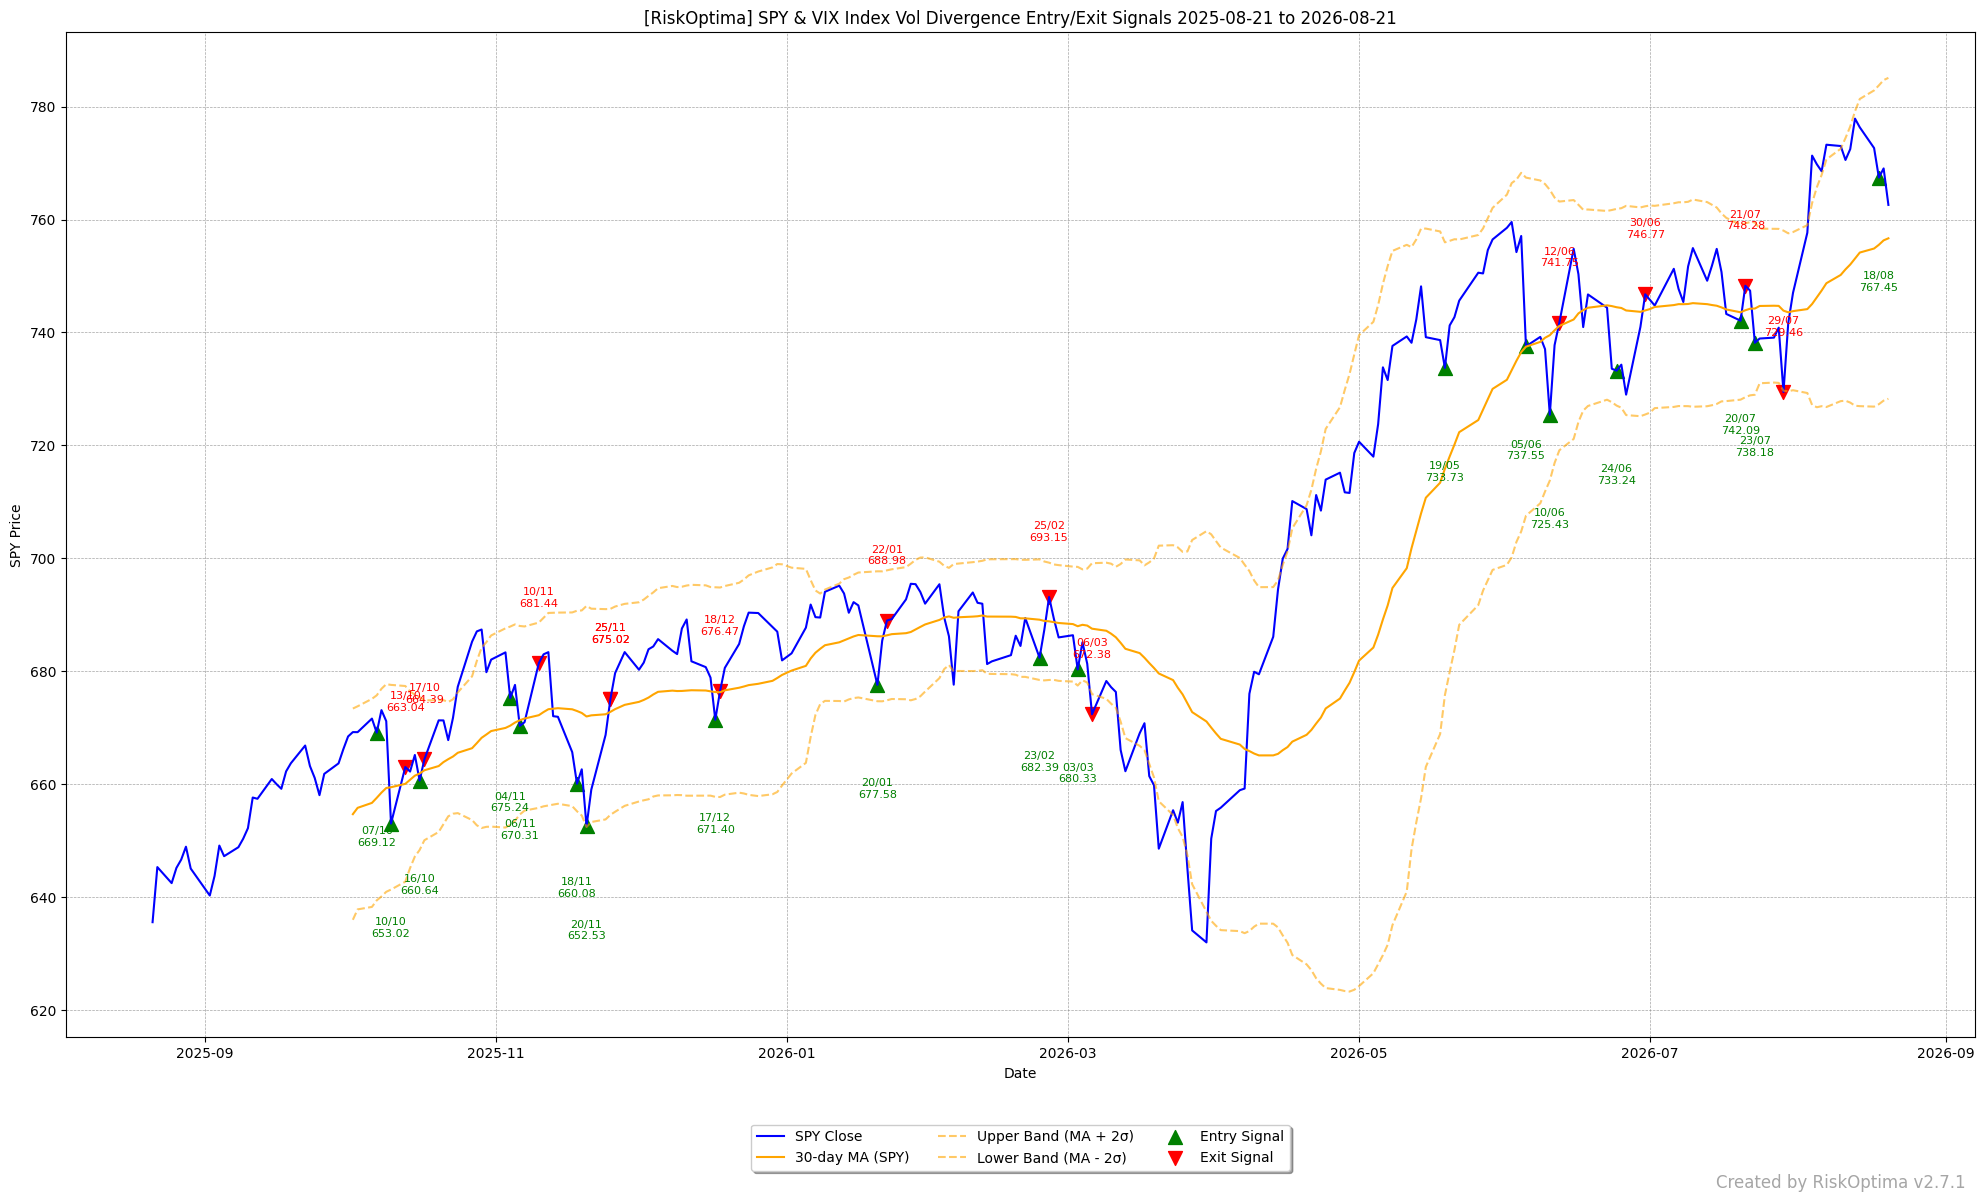

In [3]:
ANALYSIS_START_DATE = RiskOptima.get_previous_year_date(RiskOptima.get_previous_working_day(), 1)
ANALYSIS_END_DATE   = RiskOptima.get_previous_working_day()

df_signals, df_exits, returns = RiskOptima.run_index_vol_divergence_signals(start_date=ANALYSIS_START_DATE, 
                                                                            end_date=ANALYSIS_END_DATE,
                                                                            symbol_base = 'SPY')

In [5]:
df_signals

,SignalDate,base_Close,VIX_Close,Comment
0,2025-10-07,669.119995,17.240000,Second lower low + higher VIX + within ±2σ
1,2025-10-10,653.020020,21.660000,Second lower low + higher VIX + within ±2σ
2,2025-10-16,660.640015,25.309999,Second lower low + higher VIX + within ±2σ
3,2025-11-04,675.239990,19.000000,Second lower low + higher VIX + within ±2σ
4,2025-11-06,670.309998,19.500000,Second lower low + higher VIX + within ±2σ
5,2025-11-18,660.080017,24.690001,Second lower low + higher VIX + within ±2σ
6,2025-11-20,652.530029,26.420000,Second lower low + higher VIX + within ±2σ
7,2025-12-17,671.400024,17.620001,Second lower low + higher VIX + within ±2σ
8,2026-01-20,677.580017,20.090000,Second lower low + higher VIX + within ±2σ
9,2026-02-23,682.390015,21.010000,Second lower low + higher VIX + within ±2σ


In [6]:
df_exits

,EntryDate,ExitDate,EntryPrice,ExitPrice,Reason
0,2025-10-10,2025-10-13,653.020020,663.039978,Above 30-day MA
1,2025-10-16,2025-10-17,660.640015,664.390015,Above 30-day MA
2,2025-11-06,2025-11-10,670.309998,681.440002,Above 30-day MA
3,2025-11-18,2025-11-25,660.080017,675.020020,Above 30-day MA
4,2025-11-20,2025-11-25,652.530029,675.020020,Above 30-day MA
5,2025-12-17,2025-12-18,671.400024,676.469971,Above 30-day MA
6,2026-01-20,2026-01-22,677.580017,688.979980,Above 30-day MA
7,2026-02-23,2026-02-25,682.390015,693.150024,Above 30-day MA
8,2026-03-03,2026-03-06,680.330017,672.380005,Below Lower Band
9,2026-06-10,2026-06-12,725.429993,741.750000,Above 30-day MA


In [7]:
returns

,EntryDate,ExitDate,EntryPrice,ExitPrice,PnL,TotalReturn
0,2025-10-10,2025-10-13,653.020020,663.039978,0.015344,0.015344
1,2025-10-16,2025-10-17,660.640015,664.390015,0.005676,0.021020
2,2025-11-06,2025-11-10,670.309998,681.440002,0.016604,0.037625
3,2025-11-18,2025-11-25,660.080017,675.020020,0.022634,0.060258
4,2025-11-20,2025-11-25,652.530029,675.020020,0.034466,0.094724
5,2025-12-17,2025-12-18,671.400024,676.469971,0.007551,0.102275
6,2026-01-20,2026-01-22,677.580017,688.979980,0.016825,0.119100
7,2026-02-23,2026-02-25,682.390015,693.150024,0.015768,0.134868
8,2026-03-03,2026-03-06,680.330017,672.380005,-0.011686,0.123182
9,2026-06-10,2026-06-12,725.429993,741.750000,0.022497,0.145680
